#task 1 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully")

Charts folder created successfully


In [3]:
df = pd.read_csv("HR_Attrition.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
df.shape

(1470, 35)

In [7]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Target Column: Attrition")

print("\nFeature Columns:")
print(X.columns)

Target Column: Attrition

Feature Columns:
Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [8]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [9]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print("Attrition Rate:", round(attrition_rate,2), "%")

Attrition Rate: 16.12 %


In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric Columns:", len(numeric_cols))

print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


In [11]:
print("Numeric Columns:\n")

print(list(numeric_cols))

Numeric Columns:

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [12]:
print("Categorical Columns:\n")

print(list(categorical_cols))

Categorical Columns:

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


#observation

The attrition dataset is inbalanced because the number of employees who stayed is much higher than the number of employees who left the company. This inbalance should be considered while training machine learning models.

#task 2: Data Cleaning & Preprocessing

In [14]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [15]:
df = df.dropna()

print("Missing Values Removed")

Missing Values Removed


In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [20]:
df.drop(
    columns=["EmployeeNumber", "Over18", "StandardHours"],
    inplace=True,
    errors="ignore"
)

print("Columns dropped (if they existed).")

Columns dropped (if they existed).


In [21]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [26]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]
print(X.columns)

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [27]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Categorical Variables Encoded")

Categorical Variables Encoded


In [28]:
print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (1470, 45)
Target Shape: (1470,)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Scaled Successfully")

Data Scaled Successfully


In [30]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


#Task 3: Exploratory Data Analysis (EDA)

In [32]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

print(department_attrition)

Attrition                       0          1
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


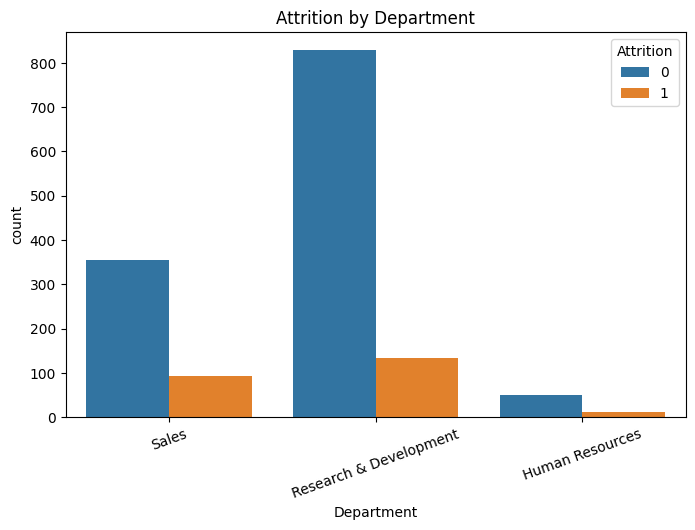

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Attrition by Department")
plt.xticks(rotation=20)

plt.savefig("charts/department_attrition.png")

plt.show()

In [34]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

print(jobrole_attrition)

Attrition                          0          1
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


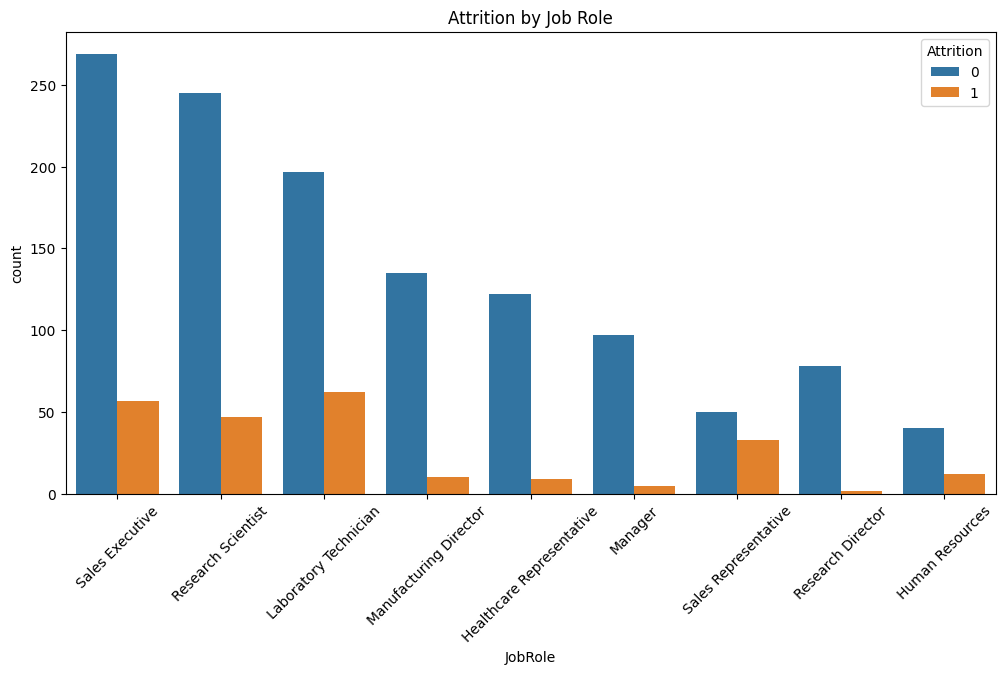

In [35]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="JobRole",
    hue="Attrition"
)

plt.xticks(rotation=45)

plt.title("Attrition by Job Role")

plt.savefig("charts/jobrole_attrition.png")

plt.show()

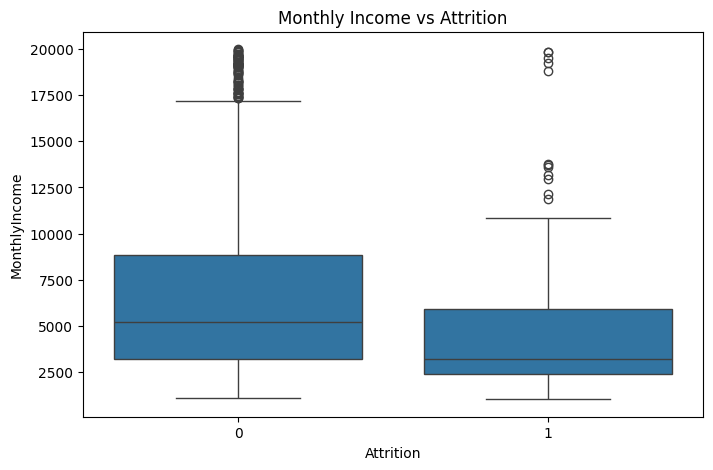

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")

plt.savefig("charts/monthlyincome_boxplot.png")

plt.show()

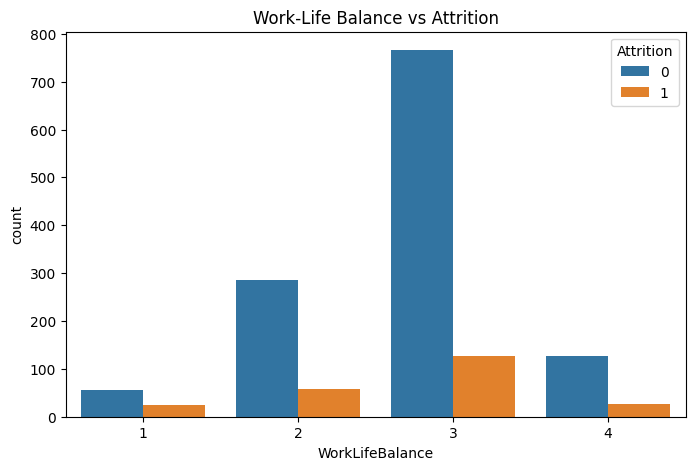

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")

plt.savefig("charts/worklifebalance.png")

plt.show()

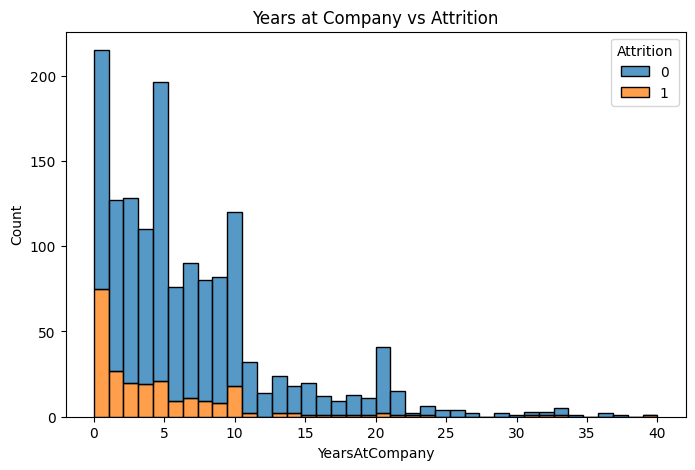

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack"
)

plt.title("Years at Company vs Attrition")

plt.savefig("charts/years_company.png")

plt.show()

Business Insights from EDA:

1. The **Sales** department has the highest employee attrition rate compared to the other departments, indicating that employees in Sales are more likely to leave the company.

2. Among different job roles, **Sales Representatives** and **Laboratory Technicians** show the highest attrition rates, suggesting these positions require greater employee retention efforts.

3. Employees with **lower monthly income** tend to leave the organization more frequently than employees with higher salaries, indicating that compensation may influence employee decisions.

4. Employees with **lower Work-Life Balance ratings (1 and 2)** show higher attrition compared to those with better work-life balance ratings, highlighting the importance of maintaining a healthy work environment.

5. Most employees who leave the company have **fewer years of service (especially within the first 5 years)**, suggesting that HR should focus on supporting and engaging employees during the early stages of their careers.


#Task 4: Model Building & Comparison

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 45)
Testing Data: (294, 45)


In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print(y_pred_lr)

[0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0
 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 1 0 1 0
 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0]


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(y_pred_rf)

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(y_pred_gb)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


#Task 5: Model Evaluation

In [45]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [46]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_gb)
    ],
    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_gb)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_gb)
    ],
    "ROC AUC":[
        roc_auc_score(y_test,y_pred_lr),
        roc_auc_score(y_test,y_pred_rf),
        roc_auc_score(y_test,y_pred_gb)
    ]
})

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.695150
1,Random Forest,0.500000,0.063830,0.113208,0.525842
2,Gradient Boosting,0.588235,0.212766,0.312500,0.592213


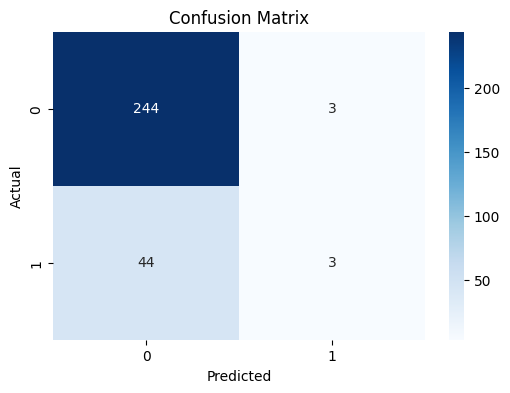

In [47]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("charts/confusion_matrix.png")

plt.show()

In [48]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top10 = importance.sort_values(ascending=False).head(10)

print(top10)

MonthlyIncome           0.071443
Age                     0.061937
TotalWorkingYears       0.054522
DailyRate               0.051280
MonthlyRate             0.047951
YearsWithCurrManager    0.046725
YearsAtCompany          0.046042
OverTime_Yes            0.043751
HourlyRate              0.043070
DistanceFromHome        0.042327
dtype: float64


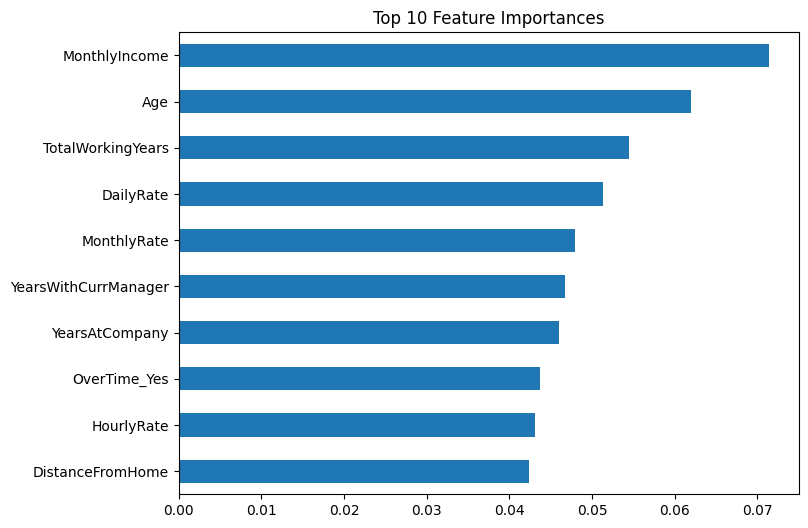

In [49]:
plt.figure(figsize=(8,6))

top10.sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances")

plt.savefig("charts/top10_features.png")

plt.show()

#Task 6 data visualization

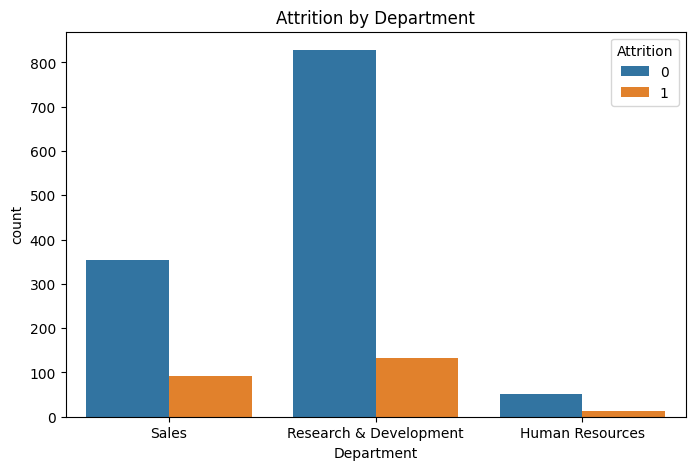

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Attrition by Department")
plt.savefig("charts/chart1.png")
plt.show()

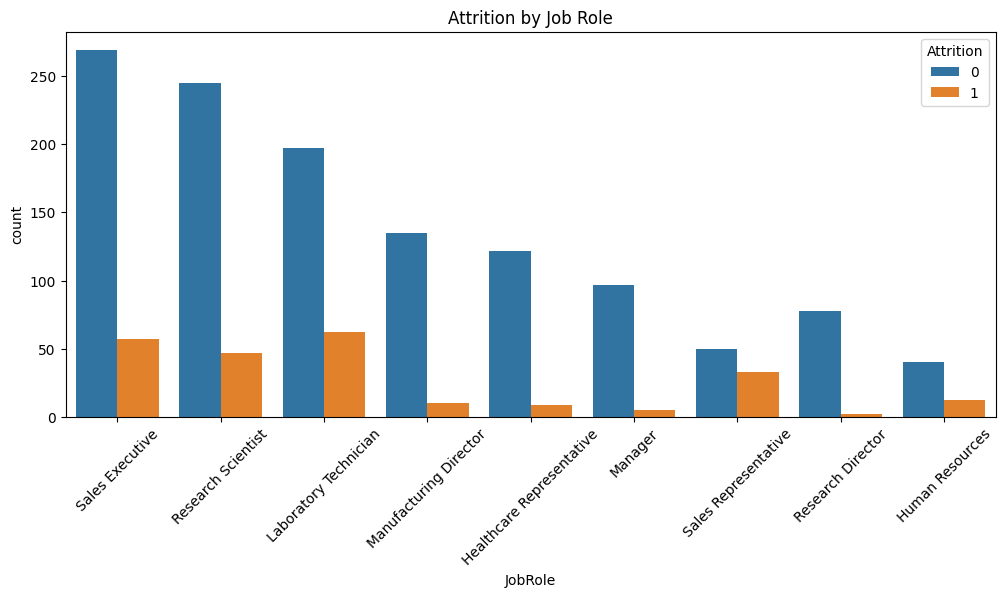

In [52]:
plt.figure(figsize=(12,5))
sns.countplot(x="JobRole", hue="Attrition", data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")
plt.savefig("charts/chart1_jobrole.png")
plt.show()

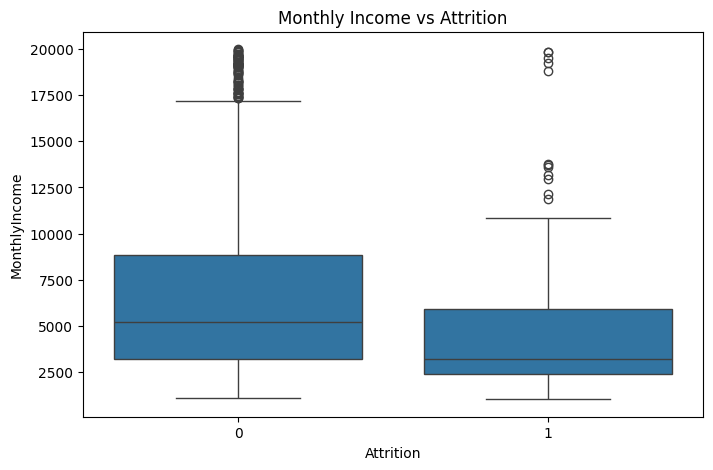

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.savefig("charts/chart2.png")
plt.show()

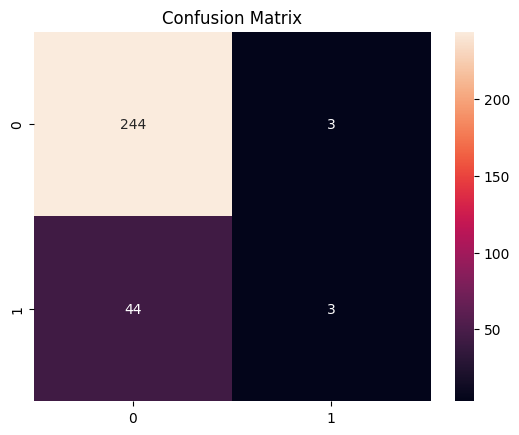

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.savefig("charts/chart3.png")
plt.show()

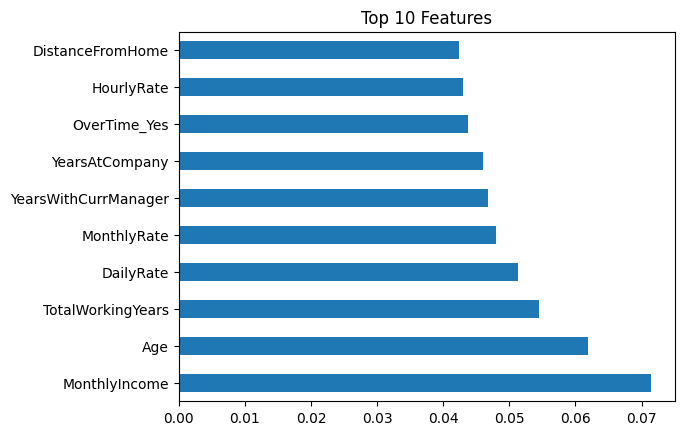

In [55]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

top10 = importance.sort_values(ascending=False).head(10)

top10.plot(kind="barh")

plt.title("Top 10 Features")
plt.savefig("charts/chart4.png")
plt.show()

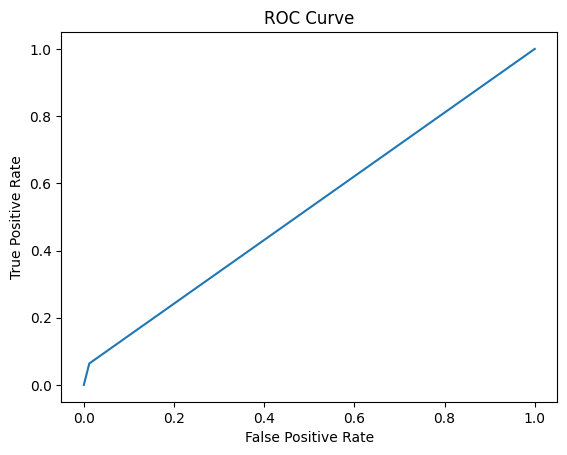

In [56]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_rf)

plt.plot(fpr, tpr)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.savefig("charts/chart5.png")
plt.show()


#Task 7 HR Insights & Business Recommendations


HR Insights & Business Recommendations:

The analysis shows that the three most important factors influencing employee attrition are monthly income, years at the company, and job role. Employees working in departments or job roles with higher attrition rates should be given priority for retention efforts by the HR team. Salary alone does not explain why employees leave, as work-life balance, career growth opportunities, and job satisfaction also play an important role. HR should conduct regular employee feedback sessions and provide better career development and training opportunities. The company should also identify employees who are at high risk of leaving and provide personalized support and retention programs. One limitation of this model is that it is based only on historical employee data and cannot consider personal reasons, future changes, or external factors that may influence an employee's decision to leave.


#Summary.docx

In [57]:
!pip install python-docx


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from docx import Document

doc = Document()

doc.add_heading("Employee Attrition Analysis - Summary", level=1)

doc.add_paragraph(
    "This project analyzed employee data to understand the main reasons why employees leave the company. "
    "The analysis found that factors such as monthly income, years at the company, job role, and work-life balance "
    "have a significant impact on employee attrition. Employees with lower salaries and fewer years of service were "
    "more likely to leave the organization."
)


doc.add_paragraph(
    "The Sales department and some specific job roles showed higher employee turnover than other departments. "
    "These groups may require additional support, regular feedback, and career development opportunities to improve employee retention."
)
doc.add_paragraph(
    "The model was evaluated using several performance measures, including ROC-AUC, which indicated that it was effective at distinguishing employees who were likely to leave from those who were likely to stay. "
    "Even though the evaluation results were good, the predictions should be used as a decision-support tool rather than the only basis for HR decisions because personal and external factors are not included in the data."
)

doc.add_paragraph(
    "The findings also suggest that salary alone does not explain employee attrition. Work-life balance, career growth, "
    "employee satisfaction, and recognition also influence an employee's decision to stay with the company."
)

doc.add_paragraph(
    "Based on these findings, HR should focus on improving employee engagement, providing training and career development programs, "
    "and conducting regular discussions with employees to identify concerns early. Special attention should be given to employees "
    "during their first few years at the company."
)


doc.add_paragraph(
    "Although this analysis provides useful insights, it is based only on historical employee data and cannot consider personal "
    "or external factors that may influence an employee's decision to leave. Therefore, these findings should be used to support "
    "HR decisions along with professional judgment."
)


doc.save("summary.docx")

print("summary.docx created successfully!")

summary.docx created successfully!
